# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset

from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import Trainer
from transformers import TrainingArguments

from sklearn.model_selection import train_test_split

W0523 16:49:11.109000 48899 torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.


# Load Dataset

In [2]:
df = pd.read_csv("../data/processed/cleaned_jobs.csv")

# Labels

In [3]:
df['label'] = df['company_rating'].apply(
    lambda x: 1 if x >= 3.5 else 0
)

# Train/Test Split

In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

# HuggingFace Dataset

In [5]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenizer

In [6]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenization Function

In [7]:
def tokenize_function(examples):
    return tokenizer(
        examples['cleaned_text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

# Apply Tokenization

In [8]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/706 [00:00<?, ? examples/s]

Map:   0%|          | 0/177 [00:00<?, ? examples/s]

# Load Model

In [9]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Training Arguments

In [10]:
import transformers

print(transformers.__version__)

4.41.2


In [11]:
training_args = TrainingArguments(
    output_dir='../outputs',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2
)

# Trainer

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Train Model

In [13]:
trainer.train()

  0%|          | 0/178 [00:00<?, ?it/s]

/Users/subhankarbiswas/glassdoor-nlp-project/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'train_runtime': 272.4685, 'train_samples_per_second': 5.182, 'train_steps_per_second': 0.653, 'train_loss': 0.6105846019273393, 'epoch': 2.0}


TrainOutput(global_step=178, training_loss=0.6105846019273393, metrics={'train_runtime': 272.4685, 'train_samples_per_second': 5.182, 'train_steps_per_second': 0.653, 'total_flos': 92878202542080.0, 'train_loss': 0.6105846019273393, 'epoch': 2.0})

# Extract Training Logs

In [14]:
logs = trainer.state.log_history

print(logs[:100])

[{'train_runtime': 272.4685, 'train_samples_per_second': 5.182, 'train_steps_per_second': 0.653, 'total_flos': 92878202542080.0, 'train_loss': 0.6105846019273393, 'epoch': 2.0, 'step': 178}]


# Extract Loss Values

In [15]:
losses = []

steps = []

for log in logs:

    if 'loss' in log:

        losses.append(log['loss'])

        steps.append(log['step'])

# Plot Training Loss

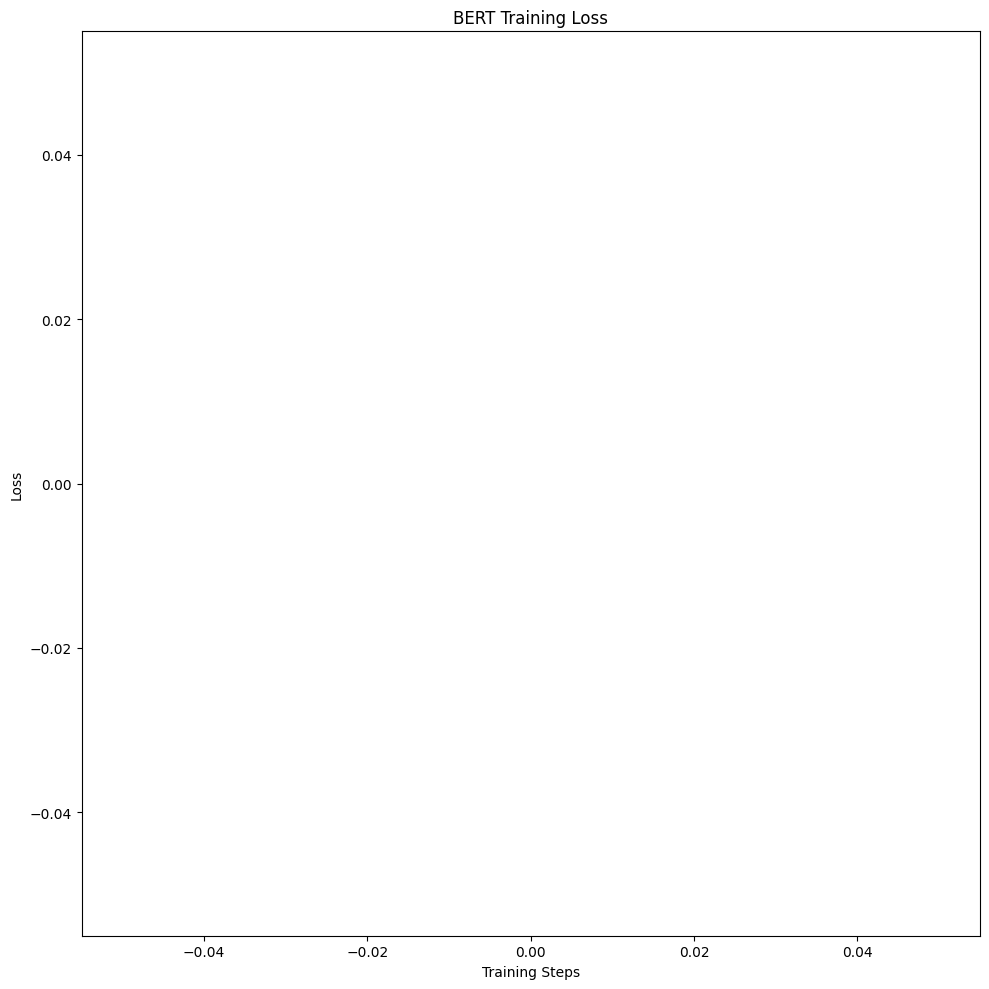

In [16]:
plt.figure(figsize=(10,10))

plt.plot(
    steps = steps + [5],
    losses = losses + [5]
)

plt.xlabel("Training Steps")

plt.ylabel("Loss")

plt.title("BERT Training Loss")

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/bert_training_loss.png"
)

plt.show()

# Evaluate

In [17]:
results = trainer.evaluate()
print(results)

  0%|          | 0/23 [00:00<?, ?it/s]

{'eval_loss': 0.5727452039718628, 'eval_runtime': 7.9323, 'eval_samples_per_second': 22.314, 'eval_steps_per_second': 2.9, 'epoch': 2.0}
